In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Load and immediately convert to 8-bit grayscale ('L')
img = np.array(Image.open('images/lady.jpg').convert('L'))


In [3]:
# 2. Apply the 2D Fast Fourier Transform (FFT)
fft_2d = np.fft.fft2(img)


In [4]:
# 3. Shift the zero-frequency (DC) component to the center
fft_shifted = np.fft.fftshift(fft_2d)


In [ ]:
# 4. Calculate the Magnitude Spectrum
# We use absolute values and a log scale (log1p handles zero safely,prevents -∞ errors)
# calculates the geometric length of the complex numbers (\(\sqrt{a^{2}+b^{2}}\))
magnitude_spectrum = np.log1p(np.abs(fft_shifted))


In [ ]:
# 5. Calculate the Phase Spectrum
# np.angle returns the phase in radians (between -pi and +pi)
#phase contains the structural data telling the frequencies exactly where to align to draw the shapes and edges of the lady.
phase_spectrum = np.angle(fft_shifted)


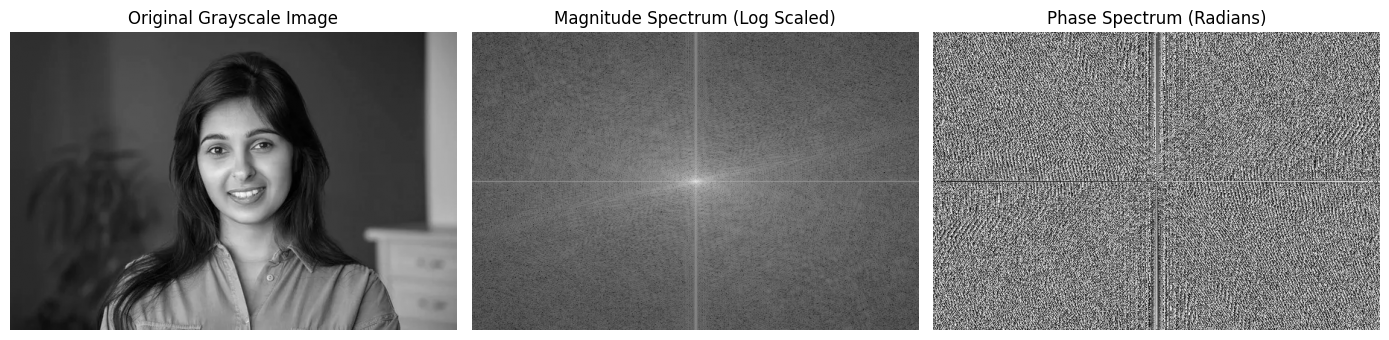

In [ ]:
# 6. Display the results
plt.figure(figsize=(14, 5))

# Original Image
plt.subplot(131)#Rows, Columns, and Index
plt.imshow(img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# Magnitude Spectrum
plt.subplot(132)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum (Log Scaled)')
plt.axis('off')

# Phase Spectrum
plt.subplot(133)
plt.imshow(phase_spectrum, cmap='gray')
plt.title('Phase Spectrum (Radians)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
#reconstructing using phase only

# 1. Extract the Phase Angle
phase_spectrum = np.angle(fft_2d)

# 2. Reconstruct complex numbers using ONLY phase
# We set the magnitude to 1 for all frequencies
# Euler's formula: e^(i * phase) = cos(phase) + i * sin(phase)
phase_only_fft = np.exp(1j * phase_spectrum)

In [9]:
# 3. Apply the Inverse 2D FFT to go back to the spatial domain
reconstructed_img = np.fft.ifft2(phase_only_fft)

# 4. Take the real part of the complex output
reconstructed_img = np.real(reconstructed_img)

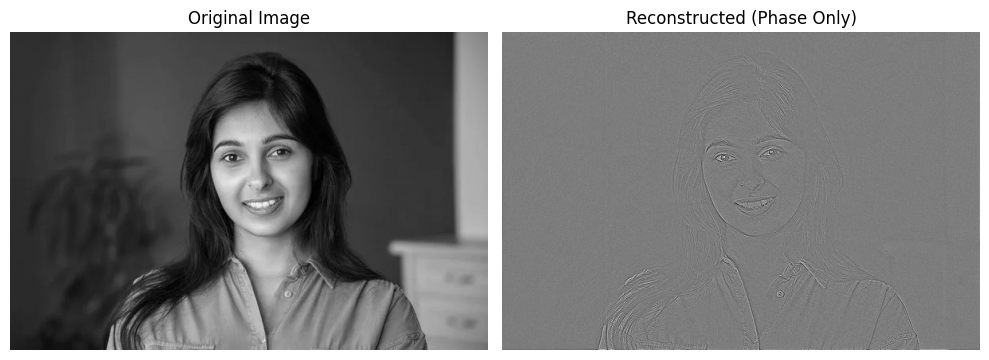

In [10]:
# 5. Display the results
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Phase-Only Reconstruction
plt.subplot(122)
plt.imshow(reconstructed_img, cmap='gray')
plt.title('Reconstructed (Phase Only)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#reconstructing using magnitude only
#(F(u,v)=|F(u,v)|* e^{j *phi (u,v)})
# |F(u,v)| is the Magnitude Spectrum (amplitude).φ(u,v) is the Phase Spectrum (angle)

# 1. Extract the Magnitude Spectrum
magnitude_spectrum = np.abs(fft_2d)

# 2. Reconstruct complex numbers using ONLY magnitude
# We destroy the spatial structure by setting all phase angles to 0
# Euler's formula with phase=0: magnitude * e^(i * 0) = magnitude * (1 + 0j)
magnitude_only_fft = magnitude_spectrum * np.exp(1j * 0)

In [12]:
# 3. Apply the Inverse 2D FFT to go back to the spatial domain
reconstructed_img = np.fft.ifft2(magnitude_only_fft)

# 4. Take the real part of the complex output
reconstructed_img = np.real(reconstructed_img)

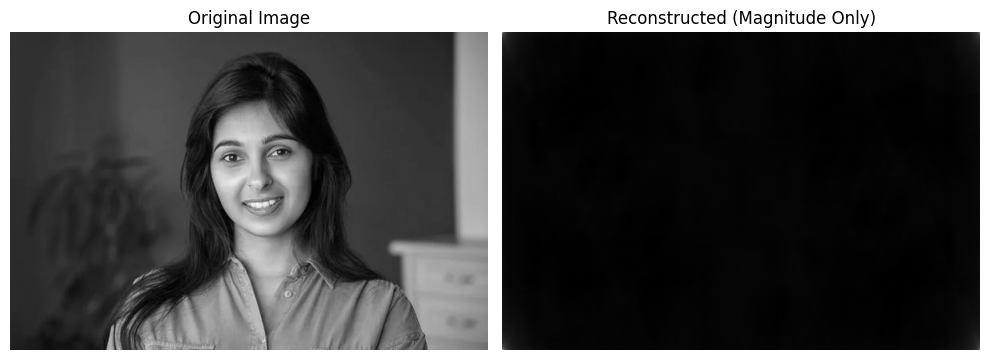

In [15]:
# 5. Display the results
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Magnitude-Only Reconstruction
plt.subplot(122)
plt.imshow(reconstructed_img, cmap='gray')
#plt.imshow(np.log1p(np.abs(reconstructed_img)), cmap='gray')#by scaling 
plt.title('Reconstructed (Magnitude Only)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
#reconstruct using both phase and magnitude spectrum

# 1. Extract BOTH Magnitude and Phase Spectrum
magnitude_spectrum = np.abs(fft_2d)
phase_spectrum = np.angle(fft_2d)

# 2. Reconstruct the original complex numbers using BOTH components
# Euler's formula: magnitude * e^(i * phase)
recombined_fft = magnitude_spectrum * np.exp(1j * phase_spectrum)

In [17]:
# 3. Apply the Inverse 2D FFT to go back to the spatial domain
reconstructed_img = np.fft.ifft2(recombined_fft)

# 4. Take the real part of the complex output
reconstructed_img = np.real(reconstructed_img)

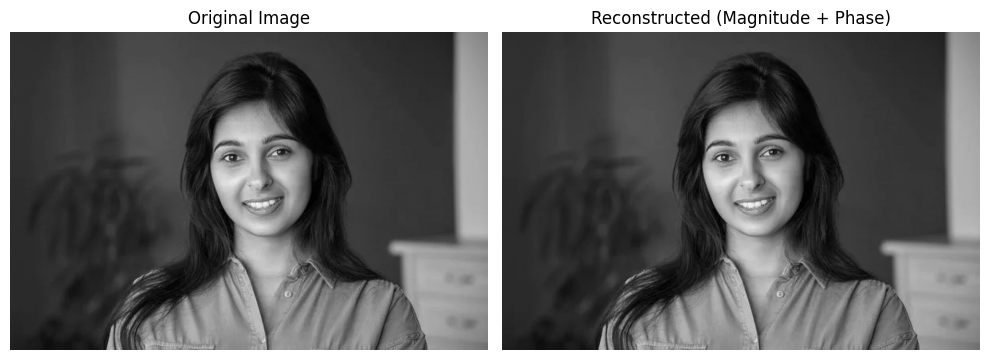

In [18]:
# 5. Display the results
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Full Reconstruction
plt.subplot(122)
plt.imshow(reconstructed_img, cmap='gray')
plt.title('Reconstructed (Magnitude + Phase)')
plt.axis('off')

plt.tight_layout()
plt.show()